In [1]:
import warnings
warnings.filterwarnings("ignore")

import pathlib
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.svm import SVC

RANDOM_STATE = 42

## 1) Load Dataset Metrics CSV

In [2]:
OUTPUT_PATH = pathlib.Path("../output")
TRAIN_SECTION = "training_set"
TEST_SECTION = "testing_set"

def load_metrics(section: str) -> pd.DataFrame:
    csv_files = glob(str(OUTPUT_PATH / section / "**" / "metrics.csv"), recursive=True)
    if not csv_files:
        raise FileNotFoundError(f"Tidak ada metrics.csv ditemukan di: {OUTPUT_PATH / section}")

    df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
    df["section"] = section
    return df

train_df = load_metrics(TRAIN_SECTION)
test_df = load_metrics(TEST_SECTION)

print(f"Train rows: {len(train_df):,} | Test rows: {len(test_df):,}")
print(f"Train classes: {sorted(train_df['class_name'].dropna().unique().tolist())}")
print(f"Test classes : {sorted(test_df['class_name'].dropna().unique().tolist())}")

train_df.head()

Train rows: 3,863 | Test rows: 968
Train classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
Test classes : ['Heart', 'Oblong', 'Oval', 'Round', 'Square']


,class_name,image_file,relative_path,face_height,face_width,forehead_height,jaw_width,chin_width,chin_angle_degree,forehead_width,skeleton_angle_left,skeleton_angle_right,jidat_angle_downward,section
0,Heart,heart (35).jpg,Heart/heart (35).jpg,0.817466,0.634720,0.305936,0.525610,0.311039,106.405281,0.552511,-5.117314,8.686354,199.631714,training_set
1,Heart,heart (680).jpg,Heart/heart (680).jpg,0.849408,0.638011,0.328042,0.526694,0.304417,105.287170,0.537037,-10.060691,8.673173,153.951828,training_set
2,Heart,heart (99).jpg,Heart/heart (99).jpg,0.912541,0.632895,0.408163,0.521866,0.291603,107.177673,0.568513,-9.027613,2.675426,139.843445,training_set
3,Heart,heart (398).jpg,Heart/heart (398).jpg,0.855491,0.609685,0.353070,0.482476,0.276324,103.935043,0.438596,-9.593134,-0.795724,129.994919,training_set
4,Heart,heart (250).jpg,Heart/heart (250).jpg,0.942475,0.724964,0.365942,0.601547,0.333412,111.756516,0.648551,-7.594643,7.815293,180.000000,training_set


## 2) Preprocess + Selective Normalization

In [3]:
id_columns = ["class_name", "image_file", "relative_path", "section"]
target_col = "class_name"

candidate_features = [
    col for col in train_df.columns
    if col not in id_columns and col in test_df.columns
]

X_train_raw = train_df[candidate_features].copy()
X_test_raw = test_df[candidate_features].copy()
y_train_raw = train_df[target_col].astype(str).copy()
y_test_raw = test_df[target_col].astype(str).copy()

for col in candidate_features:
    X_train_raw[col] = pd.to_numeric(X_train_raw[col], errors="coerce")
    X_test_raw[col] = pd.to_numeric(X_test_raw[col], errors="coerce")

valid_feature_columns = [
    col for col in candidate_features
    if not (X_train_raw[col].isna().all() and X_test_raw[col].isna().all())
]

X_train_raw = X_train_raw[valid_feature_columns]
X_test_raw = X_test_raw[valid_feature_columns]

angle_columns = [
    col for col in valid_feature_columns
    if "angle" in col.lower()
]
degree_columns = [
    col for col in valid_feature_columns
    if "degree" in col.lower()
]

for col in angle_columns:
    X_train_raw[col] = X_train_raw[col].abs()
    X_test_raw[col] = X_test_raw[col].abs()

for col in degree_columns:
    X_train_raw[col] = X_train_raw[col] / 360
    X_test_raw[col] = X_test_raw[col] / 360

pass_columns = [
    col for col in valid_feature_columns
    if col not in set(angle_columns + degree_columns)
]

print("Total fitur:", len(valid_feature_columns))
print("Kolom angle (abs):", angle_columns)
print("Kolom degree (bagi 360):", degree_columns)
print("Kolom fitur lain (tanpa scaling):", pass_columns)

if not valid_feature_columns:
    raise ValueError("Tidak ada fitur valid setelah preprocessing.")

transformers = [
    (
        "impute_all_numeric",
        Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
        valid_feature_columns,
    )
]

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False,
    sparse_threshold=0,
)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)

unseen_labels = sorted(set(y_test_raw.unique()) - set(label_encoder.classes_))
if unseen_labels:
    raise ValueError(f"Ada label testing yang tidak ada di training: {unseen_labels}")

y_test = label_encoder.transform(y_test_raw)

print("Label mapping:", dict(enumerate(label_encoder.classes_)))

print("\nPreview X_train_raw (preprocessed):")
display(X_train_raw.head())

print("\nPreview X_test_raw (preprocessed):")
display(X_test_raw.head())

Total fitur: 10
Kolom angle (abs): ['chin_angle_degree', 'skeleton_angle_left', 'skeleton_angle_right', 'jidat_angle_downward']
Kolom degree (bagi 360): ['chin_angle_degree']
Kolom fitur lain (tanpa scaling): ['face_height', 'face_width', 'forehead_height', 'jaw_width', 'chin_width', 'forehead_width']
Label mapping: {0: 'Heart', 1: 'Oblong', 2: 'Oval', 3: 'Round', 4: 'Square'}

Preview X_train_raw (preprocessed):


,face_height,face_width,forehead_height,jaw_width,chin_width,chin_angle_degree,forehead_width,skeleton_angle_left,skeleton_angle_right,jidat_angle_downward
0,0.817466,0.634720,0.305936,0.525610,0.311039,0.295570,0.552511,5.117314,8.686354,199.631714
1,0.849408,0.638011,0.328042,0.526694,0.304417,0.292464,0.537037,10.060691,8.673173,153.951828
2,0.912541,0.632895,0.408163,0.521866,0.291603,0.297716,0.568513,9.027613,2.675426,139.843445
3,0.855491,0.609685,0.353070,0.482476,0.276324,0.288708,0.438596,9.593134,0.795724,129.994919
4,0.942475,0.724964,0.365942,0.601547,0.333412,0.310435,0.648551,7.594643,7.815293,180.000000



Preview X_test_raw (preprocessed):


,face_height,face_width,forehead_height,jaw_width,chin_width,chin_angle_degree,forehead_width,skeleton_angle_left,skeleton_angle_right,jidat_angle_downward
0,0.848460,0.649766,0.324873,0.528016,0.299492,0.313627,0.604061,5.710593,9.188836,197.758301
1,0.854594,0.609091,0.331818,0.495475,0.277273,0.300286,0.600000,10.437474,10.573523,183.912903
2,0.863597,0.625445,0.367925,0.502912,0.284205,0.292698,0.514151,9.668669,11.309932,114.795166
3,0.830054,0.630716,0.372943,0.495514,0.279761,0.286648,0.610603,13.940590,17.130300,172.883041
4,0.854671,0.605098,0.343023,0.500135,0.273256,0.291696,0.406977,9.130177,3.179830,135.784821


## 3) Model Selection (Sklearn CV)

In [4]:
models = {
    "XGBoost (utama)": xgb.XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "SVM RBF": SVC(
        C=3,
        kernel="rbf",
        gamma="scale",
        probability=True,
        random_state=RANDOM_STATE,
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=11,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for model_name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("model", model)])
    scores = cross_validate(
        pipe,
        X_train_raw,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1_weighted"],
        n_jobs=-1,
        return_train_score=False,
    )

    cv_rows.append(
        {
            "model": model_name,
            "cv_accuracy_mean": np.mean(scores["test_accuracy"]),
            "cv_accuracy_std": np.std(scores["test_accuracy"]),
            "cv_f1_weighted_mean": np.mean(scores["test_f1_weighted"]),
        }
    )

cv_results = pd.DataFrame(cv_rows).sort_values(by="cv_accuracy_mean", ascending=False).reset_index(drop=True)
cv_results

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_weighted_mean
0,XGBoost (utama),0.624387,0.013357,0.623648
1,Random Forest,0.620757,0.017372,0.618946
2,Logistic Regression,0.508148,0.015388,0.483192
3,SVM RBF,0.299505,0.009384,0.259822
4,KNN,0.288115,0.013043,0.282257


## 4) Hyperparameter Tuning Khusus XGBoost
XGBoost tetap jadi fokus utama, jadi kita tuning pakai `GridSearchCV` dari sklearn.

In [5]:
xgb_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "model",
            xgb.XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

param_grid = {
    "model__n_estimators": [200, 350],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.03, 0.07],
    "model__subsample": [0.85, 1.0],
    "model__colsample_bytree": [0.85],
    "model__reg_lambda": [1.0, 2.0],
}

xgb_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train_raw, y_train)

print("Best CV Accuracy:", round(xgb_search.best_score_, 4))
print("Best Params:", xgb_search.best_params_)

pd.DataFrame(xgb_search.cv_results_)[["mean_test_score", "std_test_score", "params"]] \
    .sort_values(by="mean_test_score", ascending=False) \
    .head(10)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best CV Accuracy: 0.6296
Best Params: {'model__colsample_bytree': 0.85, 'model__learning_rate': 0.07, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__reg_lambda': 2.0, 'model__subsample': 0.85}


,mean_test_score,std_test_score,params
26,0.629566,0.014882,"{'model__colsample_bytree': 0.85, 'model__lear..."
12,0.629305,0.011531,"{'model__colsample_bytree': 0.85, 'model__lear..."
14,0.629046,0.009583,"{'model__colsample_bytree': 0.85, 'model__lear..."
30,0.628531,0.015095,"{'model__colsample_bytree': 0.85, 'model__lear..."
24,0.628011,0.012704,"{'model__colsample_bytree': 0.85, 'model__lear..."
6,0.627487,0.013561,"{'model__colsample_bytree': 0.85, 'model__lear..."
10,0.626972,0.008927,"{'model__colsample_bytree': 0.85, 'model__lear..."
20,0.626459,0.016329,"{'model__colsample_bytree': 0.85, 'model__lear..."
28,0.625943,0.010251,"{'model__colsample_bytree': 0.85, 'model__lear..."
4,0.625934,0.011938,"{'model__colsample_bytree': 0.85, 'model__lear..."


## 5) Train Final Models + Evaluate di Testing Set

In [6]:
trained_models = {
    "XGBoost (baseline)": Pipeline(
        steps=[("prep", preprocessor), ("model", models["XGBoost (utama)"])]
    ),
    "XGBoost (tuned)": xgb_search.best_estimator_,
    "Random Forest": Pipeline(
        steps=[("prep", preprocessor), ("model", models["Random Forest"])]
    ),
    "SVM RBF": Pipeline(
        steps=[("prep", preprocessor), ("model", models["SVM RBF"])]
    ),
    "Logistic Regression": Pipeline(
        steps=[("prep", preprocessor), ("model", models["Logistic Regression"])]
    ),
    "KNN": Pipeline(
        steps=[("prep", preprocessor), ("model", models["KNN"])]
    ),
}

test_rows = []
test_predictions = {}

for model_name, estimator in trained_models.items():
    estimator.fit(X_train_raw, y_train)
    y_pred = estimator.predict(X_test_raw)
    test_predictions[model_name] = y_pred

    test_rows.append(
        {
            "model": model_name,
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        }
    )

test_results = pd.DataFrame(test_rows).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
test_results

,model,test_accuracy,test_f1_weighted
0,XGBoost (baseline),0.638430,0.636086
1,XGBoost (tuned),0.638430,0.635036
2,Random Forest,0.636364,0.635533
3,Logistic Regression,0.502066,0.466703
4,SVM RBF,0.335744,0.289249
5,KNN,0.318182,0.311614


Best model on testing_set: XGBoost (baseline)

              precision    recall  f1-score   support

       Heart     0.6378    0.6345    0.6361       197
      Oblong     0.7850    0.8093    0.7970       194
        Oval     0.4624    0.4124    0.4360       194
       Round     0.5845    0.6436    0.6127       188
      Square     0.7031    0.6923    0.6977       195

    accuracy                         0.6384       968
   macro avg     0.6346    0.6384    0.6359       968
weighted avg     0.6350    0.6384    0.6361       968



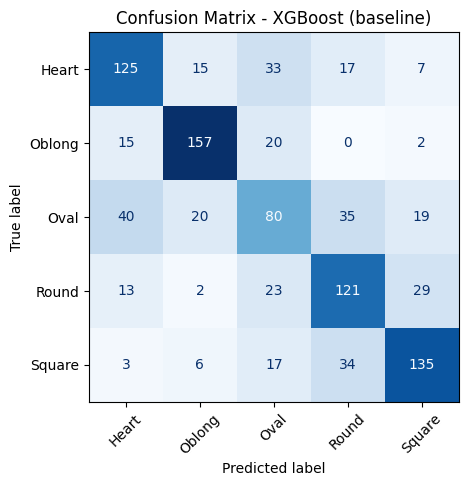

In [7]:
best_model_name = test_results.loc[0, "model"]
best_pred = test_predictions[best_model_name]

print(f"Best model on testing_set: {best_model_name}")
print()
print(
    classification_report(
        y_test,
        best_pred,
        target_names=label_encoder.classes_,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False,
    values_format="d",
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [ ]:
analysis_dir = OUTPUT_PATH / TEST_SECTION / "_analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

cv_results_path = analysis_dir / "model_selection_cv_results.csv"
test_results_path = analysis_dir / "model_comparison_test_results.csv"

cv_results.to_csv(cv_results_path, index=False)
test_results.to_csv(test_results_path, index=False)

print(f"CV results saved to: {cv_results_path}")
print(f"Test comparison saved to: {test_results_path}")